## **Cleaning Data in Python live training**


Welcome to this live, hands-on training where you will learn how to effectively diagnose and treat missing data in Python.

The majority of data science work often revolves around pre-processing data, and making sure it's ready for analysis. In this session, we will be covering how transform our raw data into accurate insights. In this notebook, you will learn:

* Import data into `pandas`, and use simple functions to diagnose problems in our data.
* Visualize missing and out of range data using `missingno` and `seaborn`.
* Apply a range of data cleaning tasks that will ensure the delivery of accurate insights.

## **The Dataset**

The dataset to be used in this webinar is a CSV file named `airbnb.csv`, which contains data on airbnb listings in the state of New York. It contains the following columns:

- `listing_id`: The unique identifier for a listing
- `description`: The description used on the listing
- `host_id`: Unique identifier for a host
- `host_name`: Name of host
- `neighbourhood_full`: Name of boroughs and neighbourhoods
- `coordinates`: Coordinates of listing _(latitude, longitude)_
- `Listing added`: Date of added listing
- `room_type`: Type of room
- `rating`: Rating from 0 to 5.
- `price`: Price per night for listing
- `number_of_reviews`: Amount of reviews received
- `last_review`: Date of last review
- `reviews_per_month`: Number of reviews per month
- `availability_365`: Number of days available per year
- `Number of stays`: Total number of stays thus far


## **Getting started**

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt

In [3]:
# Read in the dataset
airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')

## **Diagnosing data cleaning problems using simple `pandas` and visualizations**

Some important and common methods needed to get a better understanding of DataFrames and diagnose potential data problems are the following:

- `.head()` prints the header of a DataFrame
- `.dtypes` prints datatypes of all columns in a DataFrame
- `.info()` provides a bird's eye view of column data types and missing values in a DataFrame
- `.describe()` returns a distribution of numeric columns in your DataFrame
- `.isna().sum()` allows us to break down the number of missing values per column in our DataFrame
- `.unique()` finds the number of unique values in a DataFrame column

<br>

- `sns.histplot()` plots the distribution of one column in your DataFrame.

In [4]:
# Print the header of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


Printing the data types confirms that `coordinates` and `price` need to be converted to `float`, and date columns need to be converted to `datetime` _(**problems 1,2 3)**_

In [5]:
# Print info of DataFrame
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 10019 entries, 0 to 10018
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  str    
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  str    
 4   neighbourhood_full  10019 non-null  str    
 5   coordinates         10019 non-null  str    
 6   room_type           10019 non-null  str    
 7   price               9781 non-null   str    
 8   number_of_reviews   10019 non-null  int64  
 9   last_review         7944 non-null   str    
 10  reviews_per_month   7944 non-null   float64
 11  availability_365    10019 non-null  int64  
 12  rating              7944 non-null   float64
 13  number_of_stays     7944 non-null   float64
 14  5_stars             7944 non-null   float64
 15  listing_added       10019 non-null  str    
dtypes: float64(4), 

Printing the info confirms our hunch about the following:

- There is missing data in the `price`, `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` columns. It also seems that the missingness of `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, `5_stars` are related since they have the same amount of missing data. We will confirm later with `missingno` _(**problem 4**)_.

In [6]:
# Print number of missing values
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
dtype: int64

There are a variety of ways of dealing with missing data that is dependent on type of missingness, as well as the business assumptions behind our data - our options could be:

- Dropping missing data (if the data dropped does not impact or skew our data)
- Setting to missing and impute with statistical measures (median, mean, mode ...)
- Imputing with more complex algorithmic/machine learning based approaches
- Impute based on business assumptions of our data

In [7]:
# Print description of DataFrame
airbnb.describe()

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339




- **Problem 7:** Looking at the maximum of the `rating` column - we see that it is out of range of `5` which is the maximum rating possible. We need to make sure we fix the range this column.

It's worth noting that `.describe()` does not offer a bird's eye view of all the out of range data we have, for example, what if we have date data in the future? Or given our dataset, `listing_added` dates that are in the future of `last_review` dates?

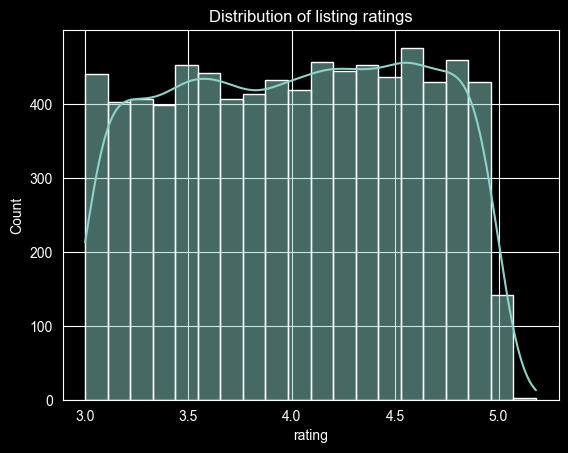

In [8]:
# Visualize the distribution of the rating column
sns.histplot(airbnb['rating'], kde=True, bins = 20)
plt.title('Distribution of listing ratings')
plt.show()

In [9]:
# Find number of unique values in room_type column
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

- **Problem 8**: There are trailing spaces and capitalization issues with `room_type`, we need to fix this problem.

In [10]:
# How many values of different room_types do we have?
airbnb['room_type'].value_counts()

room_type
Entire home/apt         5120
Private room            4487
Shared room              155
Private                   89
   Shared room            71
home                      66
PRIVATE ROOM              31
Name: count, dtype: int64

In [11]:
airbnb['price'].head(5)

0     45$
1    135$
2    150$
3     86$
4    160$
Name: price, dtype: str

## **Our to do list:**

_Data type problems:_

- **Task 1**: Split `coordinates` into 2 columns and convert them to `float`
- **Task 2**: Remove `$` from `price` and convert it to `float`
- **Task 3**: Convert `listing_added` and `last_review` to `datetime`

<br>

_Text/categorical data problems:_

- **Task 4**: We need to collapse `room_type` into correct categories
- **Task 5**: Divide `neighbourhood_full` into 2 columns and making sure they are clean

<br>

_Data range problems:_

- **Task 6**: Make sure we set the correct maximum for `rating` column out of range values

<br>

_Dealing with missing data:_

- **Task 7**: Understand the type of missingness, and deal with the missing data in most of the remaining columns.

<br>

_Is that all though?_

- We need to investigate if we duplicates in our data
- We need to make sure that data makes sense by applying some sanity checks on our DataFrame

## **Q&A**

## **Cleaning data**

### Data type problems

In [12]:
# Reminder of the DataFrame
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


##### **Task 1:** Replace `coordinates` with `latitude` and `longitude` columns

To perform this task, we will use the following methods:

- `.str.replace("","")` replaces one string in each row of a column with another
- `.str.split("")` takes in a string and lets you split a column into two based on that string
- `.astype()` lets you convert a column from one type to another

In [13]:
#removing ()
airbnb['coordinates'] = airbnb['coordinates'].str.replace('(', '').str.replace(')', '').str.replace(' ', '')

#splitting into 2 columns
airbnb[['latitude', 'longitude']] = airbnb['coordinates'].str.split(',', expand=True)

# convert to float
airbnb['latitude'] = airbnb['latitude'].astype(float)
airbnb['longitude'] = airbnb['longitude'].astype(float)


##### **Task 2:** Remove `$` from `price` and convert it to `float`

To perform this task, we will be using the following methods:

- `.str.strip()` which removes a specified string from each row in a column
- `.astype()`

In [14]:
# Calculate mean of price without conversion
#airbnb['price'].mean()

In [15]:
# Remove $ from price before conversion to float
airbnb['price'] = airbnb['price'].str.strip("$")
# Print header to make sure change was done
airbnb['price'].head()

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: str

In [16]:
# Convert price to float
airbnb['price'] = airbnb['price'].astype('float')
# Calculate mean of price after conversion
avg = airbnb['price'].mean()
airbnb['price'] = airbnb['price'].fillna(avg)

##### **Task 3:** Convert `listing_added` and `last_review` columns to `datetime`

To perform this task, we will use the following functions:

- `pd.to_datetime(format = "")`
  - `format` takes in the desired date format `"%Y-%m-%d"`

In [17]:
# Print header of two columns
airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaN
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [18]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'], format='%Y-%m-%d')
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'], format='%Y-%m-%d')

airbnb[['listing_added', 'last_review']].dtypes

listing_added    datetime64[us]
last_review      datetime64[us]
dtype: object

### Text and categorical data problems

##### **Task 4:** We need to collapse `room_type` into correct categories

To perform this task, we will be using the following methods:

- `.str.lower()` to lowercase all rows in a string column
- `.str.strip()` to remove all white spaces of each row in a string column
- `.replace()` to replace values in a column with another

In [19]:
# Print unique values of `room_type`
airbnb['room_type'].unique()

<StringArray>
[        'Private room',      'Entire home/apt',              'Private',
          'Shared room',         'PRIVATE ROOM',                 'home',
 '   Shared room      ']
Length: 7, dtype: str

In [20]:
# Deal with capitalized values
airbnb['room_type'] = airbnb['room_type'].str.lower()
airbnb['room_type'].unique()

<StringArray>
[        'private room',      'entire home/apt',              'private',
          'shared room',                 'home', '   shared room      ']
Length: 6, dtype: str

In [21]:
# Deal with trailing spaces
airbnb['room_type'] = airbnb['room_type'].str.strip()
airbnb['room_type'].unique()

<StringArray>
['private room', 'entire home/apt', 'private', 'shared room', 'home']
Length: 5, dtype: str

In [22]:
# Replace values to 'Shared room', 'Entire place', 'Private room' and 'Hotel room' (if applicable).
mappings = {'private room': 'Private Room',
            'private': 'Private Room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place'}

# Replace values and collapse data
airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].unique()

<StringArray>
['Private Room', 'Entire place', 'Shared room']
Length: 3, dtype: str

##### **Task 5:** Divide `neighbourhood_full` into 2 columns and making sure they are clean

In [23]:
# Print header of column
airbnb['neighbourhood_full'].head()

0           Brooklyn, Flatlands
1    Manhattan, Upper West Side
2    Brooklyn, Brooklyn Heights
3    Manhattan, Upper West Side
4    Manhattan, Lower East Side
Name: neighbourhood_full, dtype: str

In [24]:
#splitting
airbnb[['borough', 'neighbourhood']] = airbnb['neighbourhood_full'].str.split(',', expand=True)

In [25]:
#space removing
airbnb['borough'] = airbnb['borough'].str.strip()
airbnb['neighbourhood'] = airbnb['neighbourhood'].str.strip()

airbnb[['borough', 'neighbourhood']].head()

,borough,neighbourhood
0,Brooklyn,Flatlands
1,Manhattan,Upper West Side
2,Brooklyn,Brooklyn Heights
3,Manhattan,Upper West Side
4,Manhattan,Lower East Side


##### **Task 6:** Make sure we set the correct maximum for `rating` column out of range values

In [26]:
airbnb['rating'] = airbnb['rating'].clip(upper=5)

airbnb['rating'].max()

np.float64(5.0)

## **Q&A**

### Dealing with missing data

The `missingno` (imported as `msno`) package is great for visualizing missing data - we will be using:

- `msno.matrix()` visualizes a missingness matrix
- `msno.bar()` visualizes a missngness barplot
- `msno.dendrogram()` visualizes all connections (clusters) between NA's
- `plt.show()` to show the plot

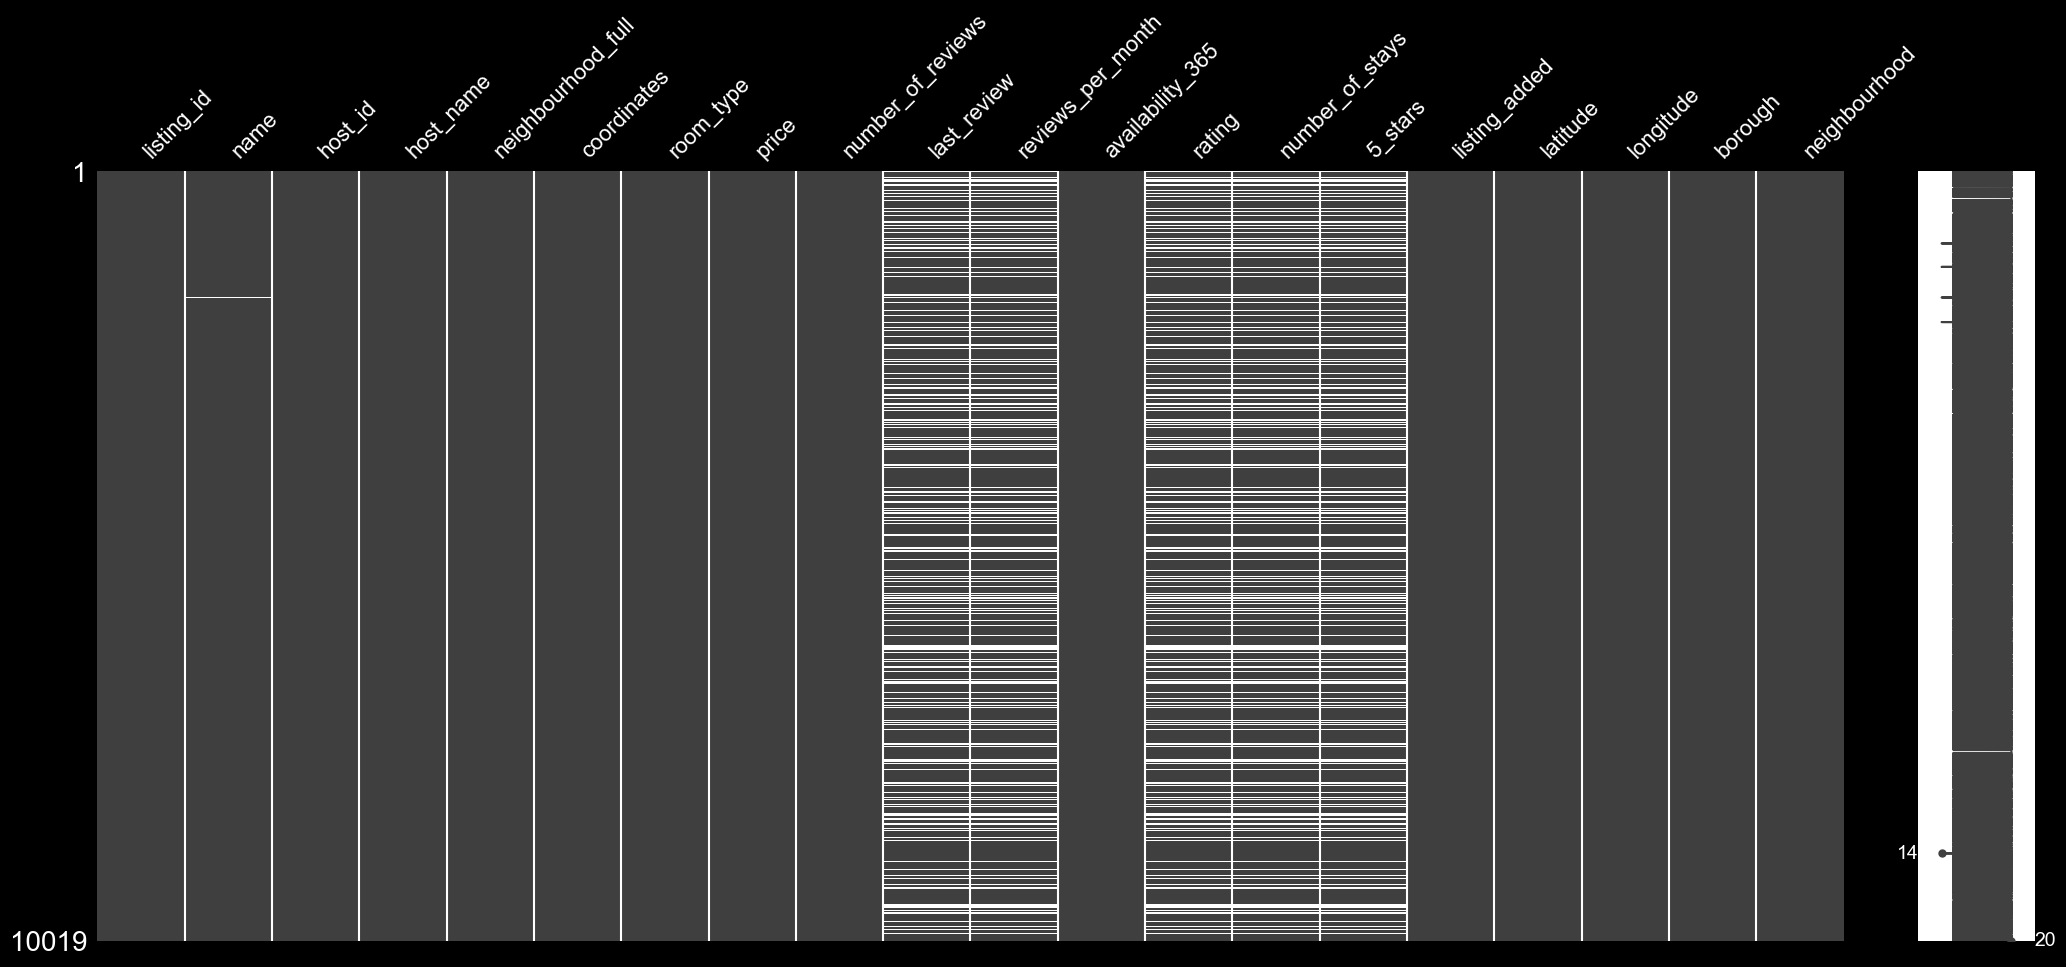

In [27]:
# Visualize the missingness
msno.matrix(airbnb)
plt.show()

Looking at the missingness matrix, we can see that missing values are almost identical between `last_review`, `reviews_per_month`, `rating`, `number_of_stays`, and `5_stars`. Let's confirm this further by sorting on `rating`.

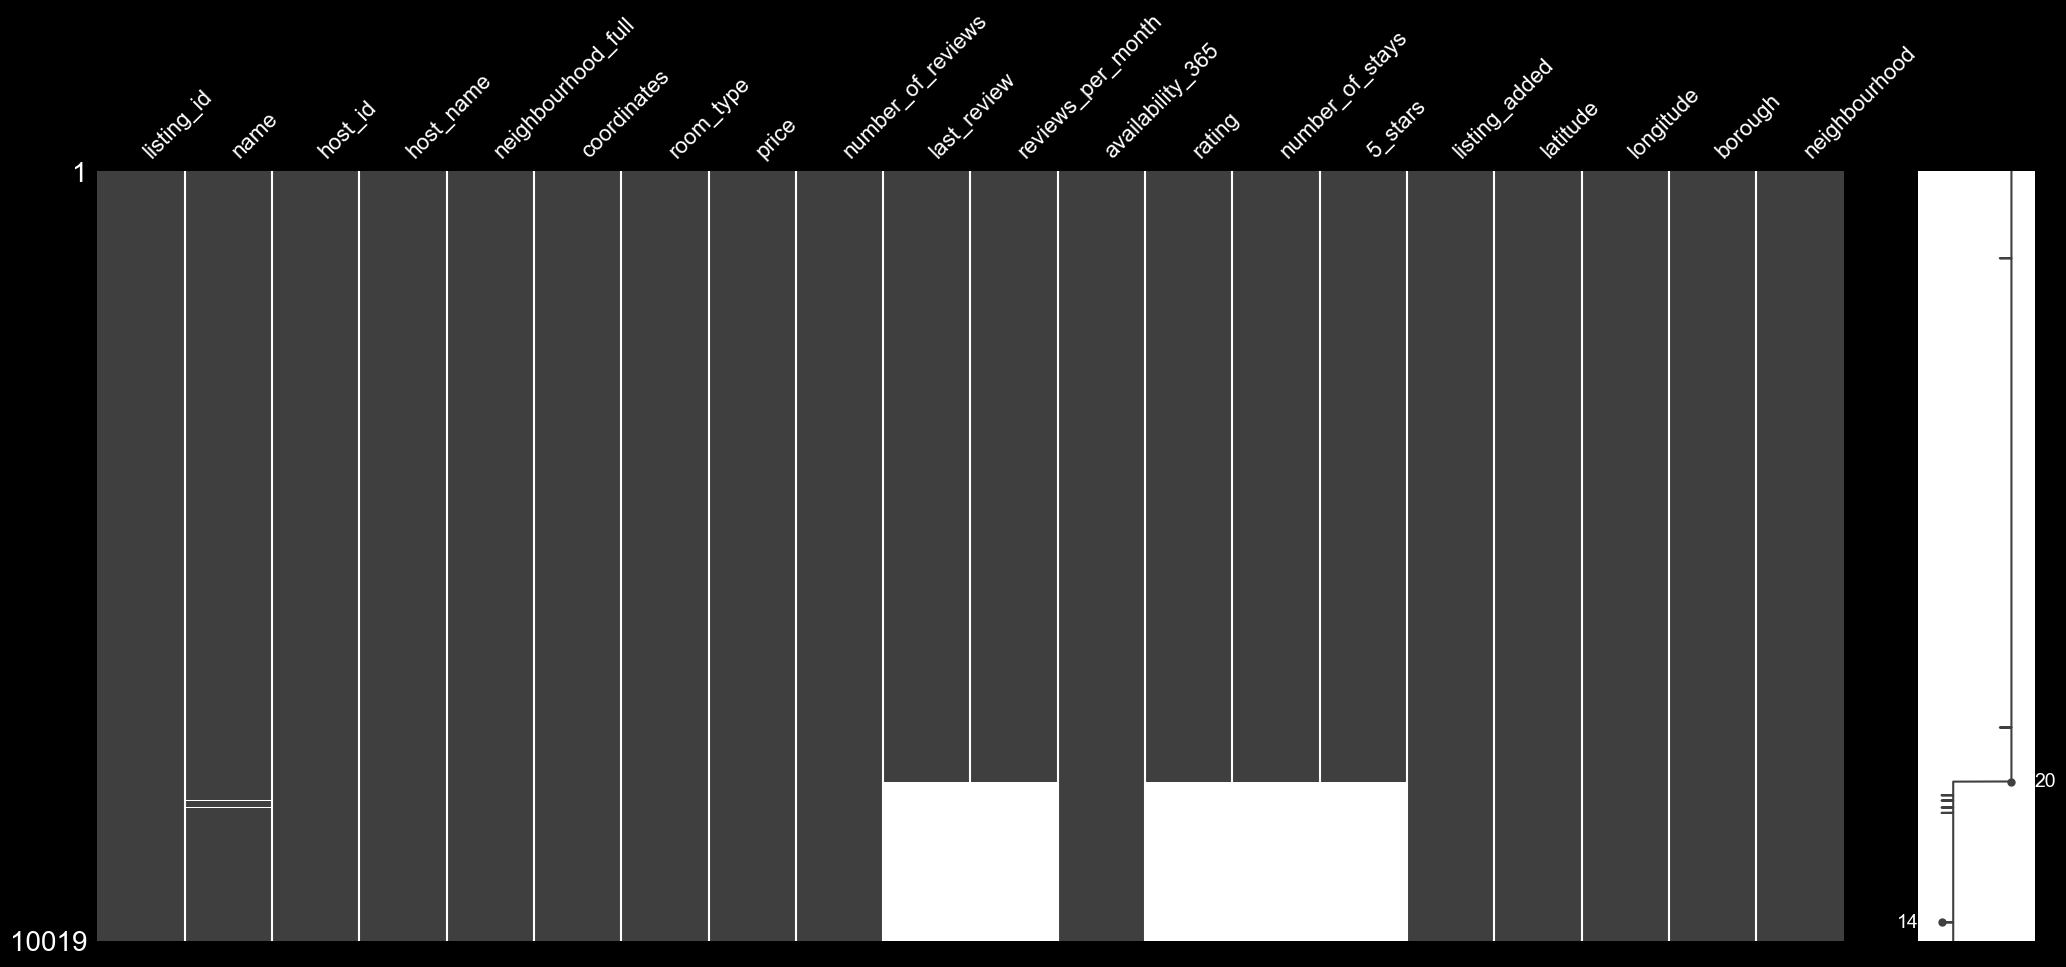

In [28]:
# Visualize the missingness on sorted values
msno.matrix(airbnb.sort_values(by = 'rating'))
plt.show()

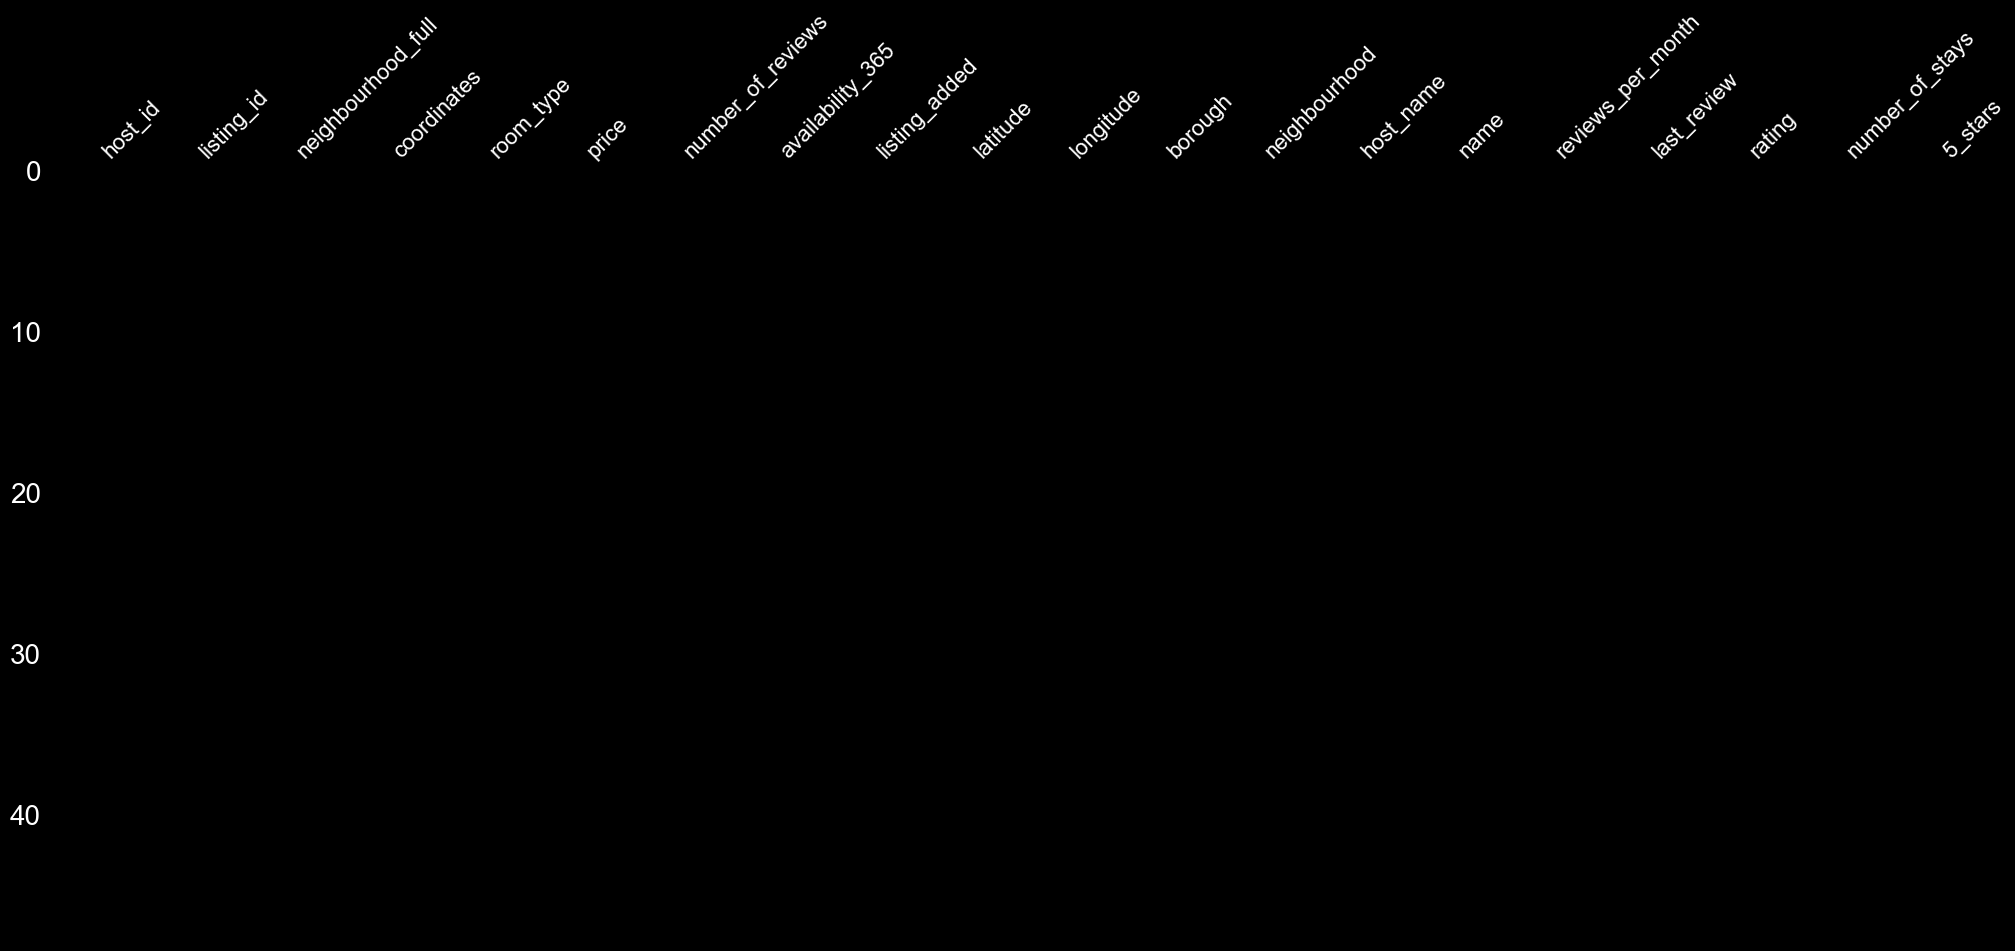

In [29]:
msno.dendrogram(airbnb)
plt.show()

<Axes: >

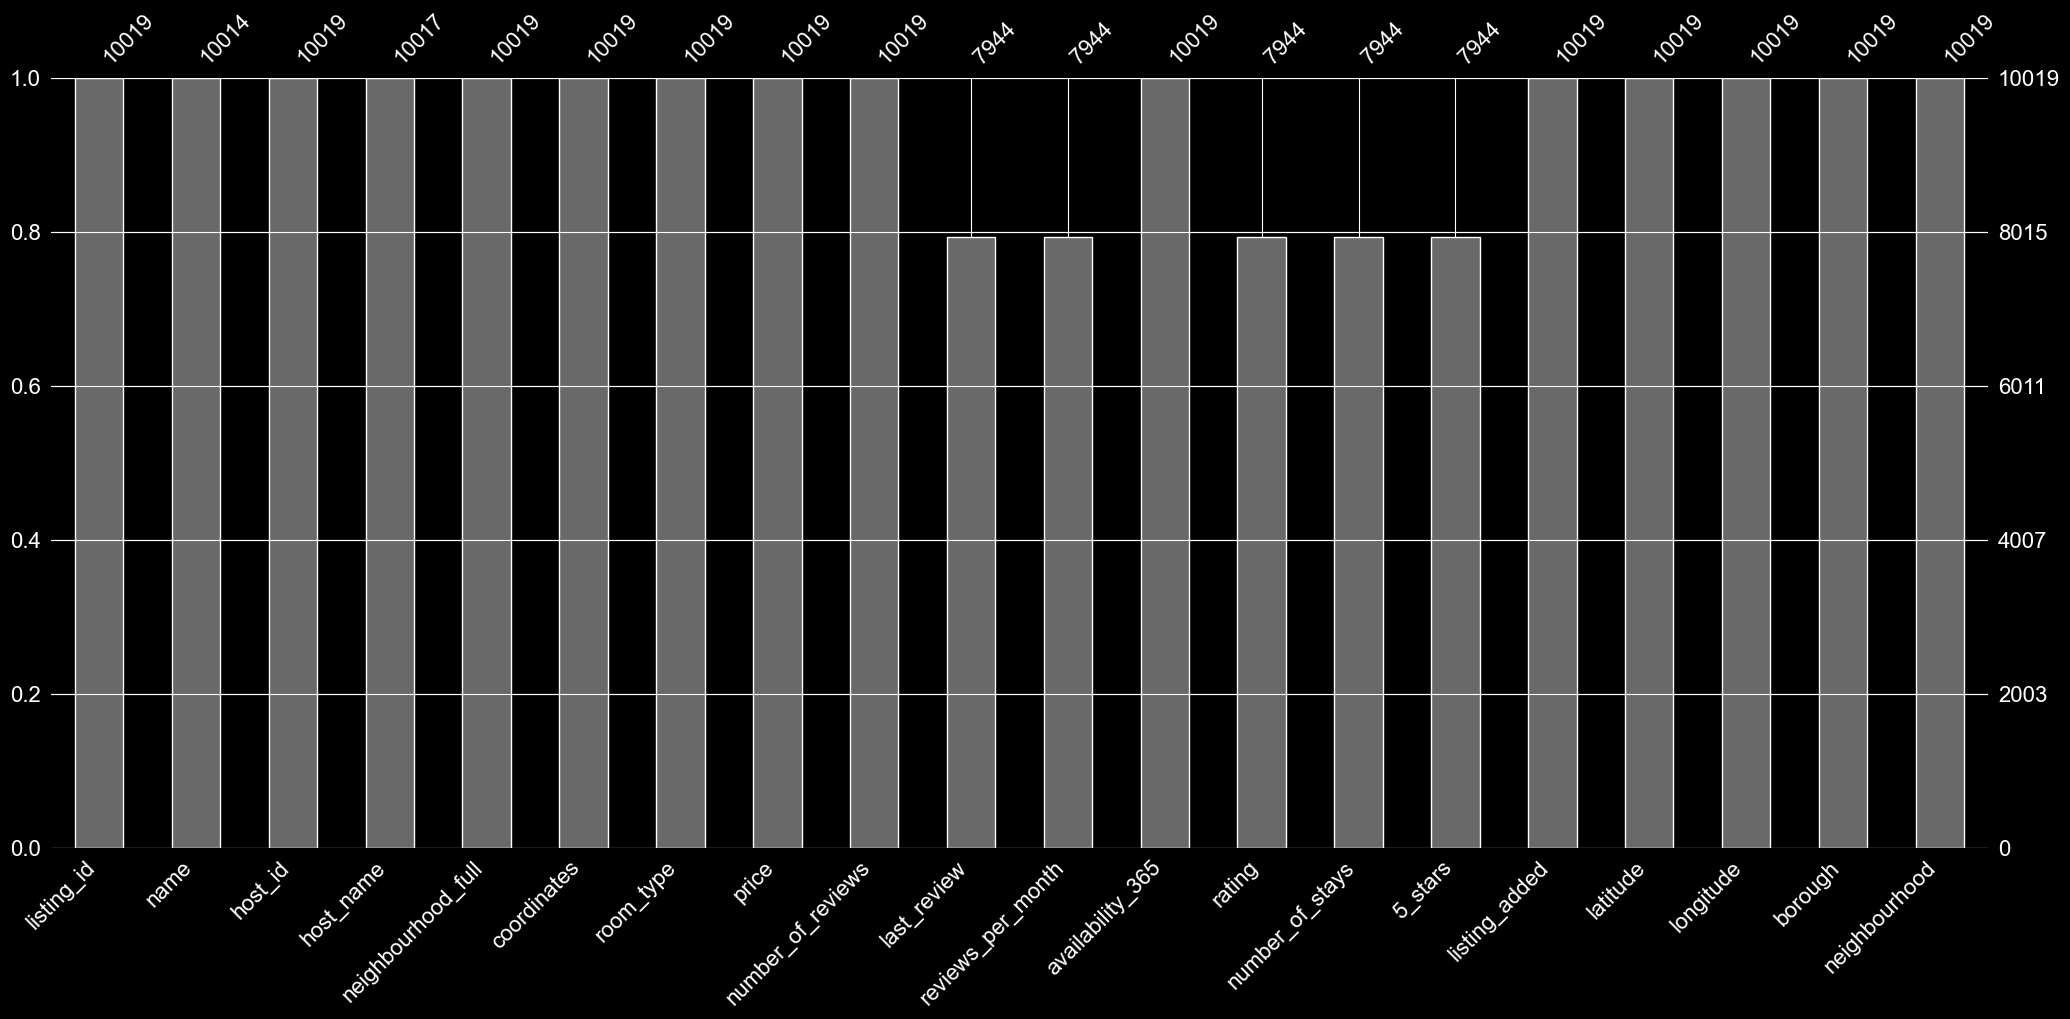

In [30]:
# Missingness barplot
msno.bar(airbnb)

**Treating the** `rating`, `number_of_stays`, `5_stars`, `reviews_per_month` **columns**

In [31]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,2.075000e+03,2.075000e+03,2075.000000,2075.0,0,0.0,2075.000000,0.0,0.0,0.0,2075,2075.000000,2075.000000
mean,2.274238e+07,8.022455e+07,190.633032,0.0,NaT,NaN,104.531566,NaN,NaN,NaN,2018-06-08 17:01:31.951807,40.732074,-73.956771
min,6.358800e+04,1.475100e+04,0.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-02-03 00:00:00,40.527000,-74.209410
25%,1.232923e+07,1.224305e+07,70.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-04-05 00:00:00,40.697845,-73.985185
50%,2.345182e+07,4.040116e+07,120.000000,0.0,NaT,NaN,7.000000,NaN,NaN,NaN,2018-06-05 00:00:00,40.727790,-73.960940
75%,3.400364e+07,1.333498e+08,200.000000,0.0,NaT,NaN,211.000000,NaN,NaN,NaN,2018-08-13 00:00:00,40.763480,-73.939540
max,3.648724e+07,2.741034e+08,5250.000000,0.0,NaT,NaN,365.000000,NaN,NaN,NaN,2018-10-17 00:00:00,40.911690,-73.727310
std,1.123730e+07,8.663163e+07,312.642005,0.0,NaN,NaN,138.266525,NaN,NaN,NaN,NaN,0.051168,0.041065


In [32]:
# Understand DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month
airbnb[~airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,7.944000e+03,7.944000e+03,7944.000000,7944.000000,7944,7944.000000,7944.000000,7944.000000,7944.000000,7944.000000,7944,7944.000000,7944.000000
mean,1.837100e+07,6.475548e+07,140.528056,28.326284,2018-10-07 03:30:05.438066,1.353894,114.309290,4.014422,33.991541,0.718599,2018-04-03 15:56:11.601208,40.728325,-73.950642
min,3.831000e+03,2.787000e+03,0.000000,1.000000,2011-03-28 00:00:00,0.010000,0.000000,3.000633,1.200000,0.600026,2010-09-22 00:00:00,40.508680,-74.239860
25%,8.970241e+06,7.137797e+06,69.000000,3.000000,2018-07-16 00:00:00,0.200000,0.000000,3.520443,3.600000,0.655576,2018-01-10 00:00:00,40.688567,-73.982152
50%,1.928118e+07,2.949374e+07,109.000000,9.000000,2019-05-19 00:00:00,0.710000,54.000000,4.027965,10.800000,0.709768,2018-11-13 00:00:00,40.721785,-73.954415
75%,2.789420e+07,1.016715e+08,169.000000,32.000000,2019-06-23 00:00:00,2.000000,229.000000,4.516378,38.400000,0.763978,2018-12-18 00:00:00,40.763360,-73.934930
max,3.641363e+07,2.733615e+08,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,5.000000,612.000000,0.950339,2020-10-23 00:00:00,40.913060,-73.719280
std,1.069161e+07,7.608428e+07,161.696882,46.741066,NaN,1.615380,129.781153,0.574998,56.089279,0.079978,NaN,0.055482,0.047013


Looking at the missing data in the DataFrame - we can see that `number_of_reviews` across all missing rows is 0. We can infer that these listings have never been visited - hence could be inferred they're inactive/have never been visited.

We can impute them as following:

- Set `NaN` for `reviews_per_month`, `number_of_stays`, `5_stars` to 0.
- Since a `rating` did not happen, let's keep the column as is - but create a new column named `rated` that takes in `1` if yes, `0` if no.
- We will also leave `last_review` as is.


In [33]:
# Impute missing data
airbnb = airbnb.fillna({'reviews_per_month':0,
                        'number_of_stays':0,
                        '5_stars':0})

# Create is_rated column
is_rated = np.where(airbnb['rating'].isna() == True, 0, 1)
airbnb['is_rated'] = is_rated

**Treating the** `price` **column**

In [34]:
# Investigate DataFrame with missing values in price
airbnb[airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,is_rated
count,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Investigate DataFrame with missing values in price
airbnb[~airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,is_rated
count,1.001900e+04,1.001900e+04,10019.000000,10019.000000,7944,10019.000000,10019.000000,7944.000000,10019.000000,10019.000000,10019,10019.000000,10019.000000,10019.000000
mean,1.927634e+07,6.795923e+07,150.905122,22.459727,2018-10-07 03:30:05.438066,1.073493,112.284260,4.014422,26.951672,0.569772,2018-04-17 08:13:07.623515,40.729102,-73.951911,0.792894
min,3.831000e+03,2.787000e+03,0.000000,0.000000,2011-03-28 00:00:00,0.000000,0.000000,3.000633,0.000000,0.000000,2010-09-22 00:00:00,40.508680,-74.239860,0.000000
25%,9.674772e+06,7.910880e+06,70.000000,1.000000,2018-07-16 00:00:00,0.040000,0.000000,3.520443,1.200000,0.611660,2018-03-08 00:00:00,40.689880,-73.982845,1.000000
50%,2.007030e+07,3.165167e+07,110.000000,5.000000,2019-05-19 00:00:00,0.370000,44.000000,4.027965,6.000000,0.681930,2018-09-09 00:00:00,40.723010,-73.955430,1.000000
75%,2.933864e+07,1.074344e+08,175.000000,22.000000,2019-06-23 00:00:00,1.550000,226.000000,4.516378,26.400000,0.750088,2018-12-14 00:00:00,40.763390,-73.936065,1.000000
max,3.648724e+07,2.741034e+08,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,5.000000,612.000000,0.950339,2020-10-23 00:00:00,40.913060,-73.719280,1.000000
std,1.095056e+07,7.863106e+07,203.417189,43.173896,NaN,1.539481,131.636043,0.574998,51.808675,0.299795,NaN,0.054636,0.045910,0.405253


From a common sense perspective, the most predictive factor for a room's price is the `room_type` column, so let's visualize how price varies by room type with `sns.boxplot()` which displays the following information:


<p align="center">
<img src="https://github.com/adelnehme/cleaning-data-in-python-live-training/blob/master/boxplot.png?raw=true" alt = "DataCamp icon" width="80%">
</p>




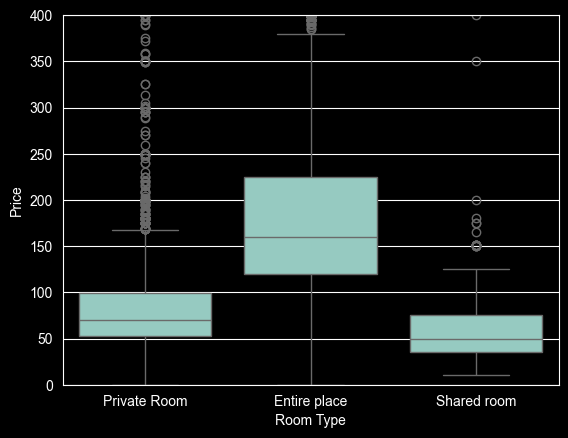

In [36]:
# Visualize relationship between price and room_type
sns.boxplot(x = 'room_type', y = 'price', data = airbnb)
plt.ylim(0, 400)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

In [37]:
# Get median price per room_type
airbnb.groupby('room_type')['price'].median()

room_type
Entire place    160.0
Private Room     70.0
Shared room      50.0
Name: price, dtype: float64

In [38]:
# Impute price based on conditions
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Entire place'), 'price'] = 163.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Private Room'), 'price'] = 70.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Shared Room'), 'price'] = 50.0

In [39]:
# Confirm price has been imputed
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                    0
number_of_reviews        0
last_review           2075
reviews_per_month        0
availability_365         0
rating                2075
number_of_stays          0
5_stars                  0
listing_added            0
latitude                 0
longitude                0
borough                  0
neighbourhood            0
is_rated                 0
dtype: int64

### What's still to be done?

Albeit we've done a significant amount of data cleaning tasks, there are still a couple of problems we have yet to diagnose. When cleaning data, we need to consider:

- Values that do not make any sense *(for example: are there values of `last_review` that older than `listing_added`? Are there listings in the future?*)
- Presence of duplicates values - and how to deal with them?

##### **Task 8:** Do we have consistent date data?

In [40]:
# Doing some sanity checks on date data
today = dt.date.today()

In [41]:
# Are there reviews in the future?
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])
airbnb[airbnb['last_review'].dt.date > today]

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated


In [42]:
# Are there listings in the future?
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])
airbnb[airbnb['listing_added'].dt.date > today]

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated


In [43]:
# Drop these rows since they are only 4 rows
airbnb = airbnb[~(airbnb['listing_added'].dt.date > today)]

In [44]:
# Are there any listings with listing_added > last_review
inconsistent_dates = airbnb[airbnb['listing_added'].dt.date > airbnb['last_review'].dt.date]
inconsistent_dates

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884,-73.98354",Private Room,160.0,23,2019-06-12,...,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354,Manhattan,Lower East Side,1
50,20783900,Marvelous Manhattan Marble Hill Private Suites,148960265,Randy,"Manhattan, Marble Hill","40.87618,-73.91266",Private Room,93.0,7,2018-10-06,...,0,4.868036,8.4,0.609263,2020-02-17,40.87618,-73.91266,Manhattan,Marble Hill,1
60,1908852,Oversized Studio By Columbus Circle,684629,Alana,"Manhattan, Upper West Side","40.7706,-73.98919000000002",Entire place,189.0,7,2016-05-06,...,0,4.841204,8.4,0.725995,2017-09-17,40.77060,-73.98919,Manhattan,Upper West Side,1
124,28659894,Private bedroom in prime Bushwick! Near Trains!!!,216235179,Nina,"Brooklyn, Bushwick","40.69988,-73.92071999999997",Private Room,55.0,4,2019-04-12,...,358,4.916252,4.8,0.703117,2020-08-23,40.69988,-73.92072,Brooklyn,Bushwick,1
511,33619855,Modern & Spacious in trendy Crown Heights,253354074,Yehudis,"Brooklyn, Crown Heights","40.66387,-73.9384",Entire place,150.0,6,2019-05-27,...,148,3.462432,7.2,0.610929,2020-10-07,40.66387,-73.93840,Brooklyn,Crown Heights,1
521,25317793,Awesome Cozy Room in The Heart of Sunnyside!,136406167,Kara,"Queens, Sunnyside","40.7409,-73.92696",Private Room,65.0,22,2019-06-11,...,131,4.442485,26.4,0.722388,2020-10-22,40.74090,-73.92696,Queens,Sunnyside,1


In [45]:
# Drop these rows since they are only 2 rows
airbnb.drop(inconsistent_dates.index, inplace = True)

##### **Task 9:** Let's deal with duplicate data


There are two notable types of duplicate data:

- Identical duplicate data across all columns
- Identical duplicate data cross most or some columns

To diagnose, and deal with duplicate data, we will be using the following methods and functions:

- `.duplicated(subset = , keep = )`
  - `subset` lets us pick one or more columns with duplicate values.
  - `keep` returns lets us return all instances of duplicate values.
- `.drop_duplicates(subset = , keep = )`
  

In [46]:
# Print the header of the DataFrame again
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222,-73.93398",Private Room,45.0,10,2018-12-12,...,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Brooklyn,Flatlands,1
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761,-73.96862",Entire place,135.0,1,2019-06-30,...,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Manhattan,Upper West Side,1
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007,-73.99517",Entire place,150.0,0,NaT,...,65,NaN,0.0,0.000000,2018-08-15,40.70070,-73.99517,Brooklyn,Brooklyn Heights,0
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169,-73.97498",Entire place,86.0,5,2017-09-23,...,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498,Manhattan,Upper West Side,1
5,271954,Beautiful brownstone apartment,1423798,Aj,"Manhattan, Greenwich Village","40.73388,-73.99452",Entire place,150.0,203,2019-06-20,...,300,4.478396,243.6,0.743500,2018-12-15,40.73388,-73.99452,Manhattan,Greenwich Village,1


In [47]:
# Find duplicates
duplicates = airbnb.duplicated()
print(f"Number of identical duplicates: {duplicates.sum()}")

Number of identical duplicates: 13


In [48]:
# Remove identical duplicates
irbnb = airbnb.drop_duplicates()

In [49]:
# Find non-identical duplicates
non_identical_duplicates = airbnb.duplicated(subset=['listing_id'], keep=False)

In [50]:
# Show all duplicates
airbnb[non_identical_duplicates].sort_values(by='listing_id')

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
1145,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,"Brooklyn, Greenpoint","40.73652,-73.95236",Entire place,199.0,43,2019-07-02,...,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236,Brooklyn,Greenpoint,1
6562,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,"Brooklyn, Greenpoint","40.73652,-73.95236",Entire place,199.0,43,2019-07-02,...,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236,Brooklyn,Greenpoint,1
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,"Brooklyn, Williamsburg","40.71257,-73.96149",Entire place,250.0,0,NaT,...,0,NaN,0.0,0.000000,2018-05-24,40.71257,-73.96149,Brooklyn,Williamsburg,0
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,"Brooklyn, Williamsburg","40.71257,-73.96149",Entire place,245.0,0,NaT,...,0,NaN,0.0,0.000000,2018-08-09,40.71257,-73.96149,Brooklyn,Williamsburg,0
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,"Brooklyn, Bedford-Stuyvesant","40.69496,-73.93949",Private Room,73.0,110,2019-06-23,...,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,"Brooklyn, Bedford-Stuyvesant","40.69496,-73.93949",Private Room,70.0,110,2019-06-23,...,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,"Manhattan, Kips Bay","40.73813,-73.98098",Entire place,280.0,4,2016-05-22,...,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,"Manhattan, Kips Bay","40.73813,-73.98098",Entire place,289.0,4,2016-05-22,...,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,"Brooklyn, Prospect-Lefferts Gardens","40.66086,-73.96159",Entire place,150.0,123,2019-07-01,...,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,"Brooklyn, Prospect-Lefferts Gardens","40.66086,-73.96159",Entire place,154.0,123,2019-07-01,...,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1


To treat identical duplicates across some columns, we will chain the `.groupby()` and `.agg()` methods where we group by the column used to find duplicates (`listing_id`) and aggregate across statistical measures for `price`, `rating` and `list_added`. The `.agg()` method takes in a dictionary with each column's aggregation method - we will use the following aggregations:

- `mean` for `price` and `rating` columns
- `max` for `listing_added` column
- `first` for all remaining column

*A note on dictionary comprehensions:*

Dictionaries are useful data structures in Python with the following format
`my_dictionary = {key: value}` where a `key` is mapped to a `value` and whose `value` can be returned with `my_dictionary[key]` - dictionary comprehensions allow us to programmatically create dicitonaries using the structure:

```
{x: x*2 for x in [1,2,3,4,5]}
{1:2, 2:4, 3:6, 4:8, 5:10}
```

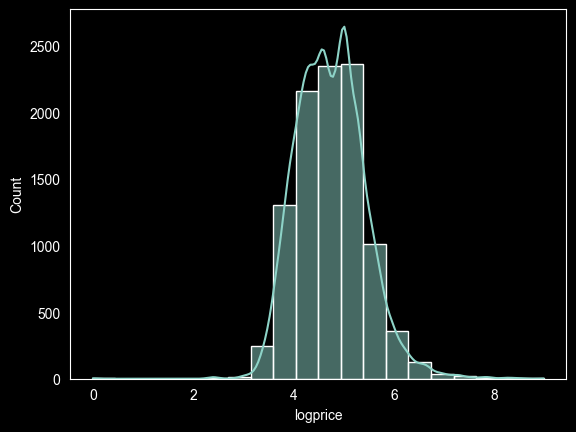

In [51]:
airbnb['logprice'] = np.log1p(airbnb['price'])
sns.histplot(airbnb['logprice'], kde=True, bins=20)
plt.grid()
plt.show()

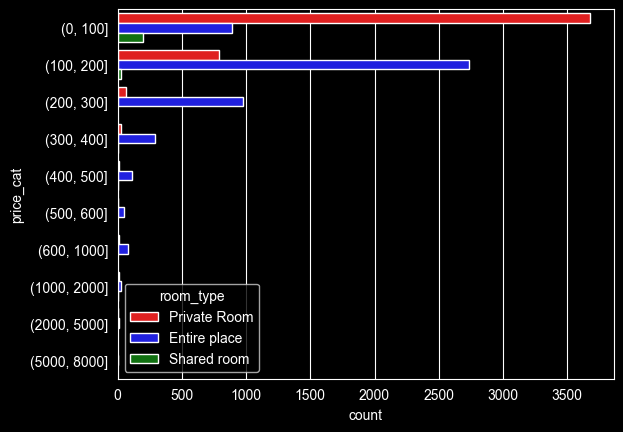

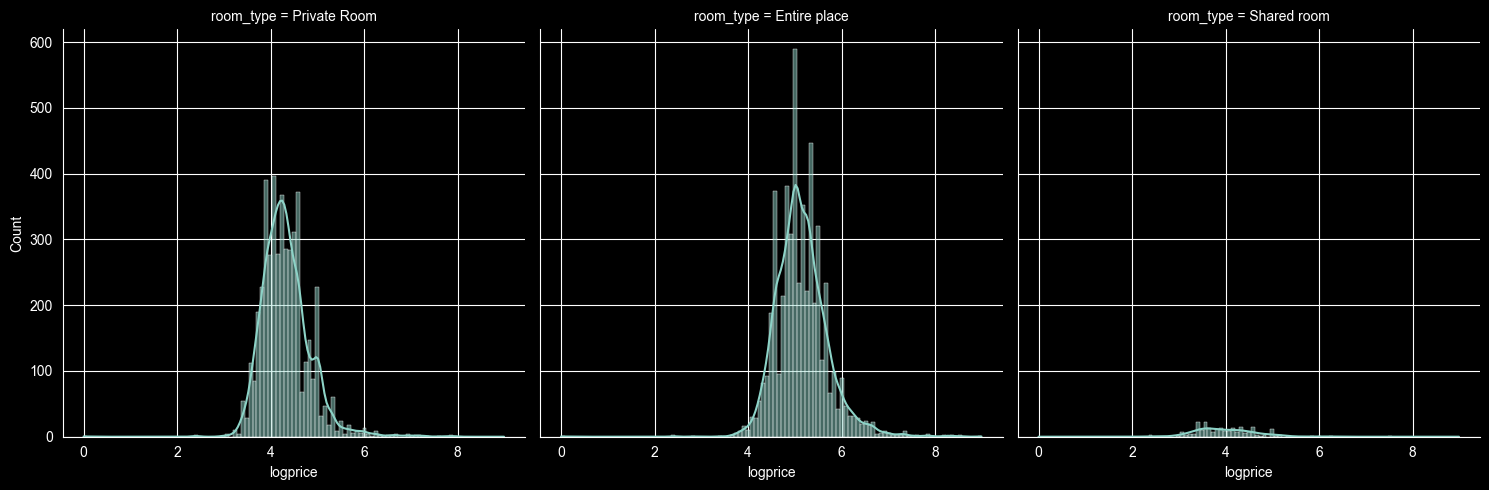

In [52]:
airbnb['price_cat'] = pd.cut(airbnb['price'], [0, 100, 200, 300, 400, 500, 600, 1000, 2000, 5000, 8000])
airbnb['price_cat'].unique

pd.crosstab(index=airbnb['price_cat'], columns=airbnb['room_type'])
sns.countplot(airbnb, y="price_cat", hue="room_type", palette=['red', 'blue', 'green']) #hue means colors

import plotly.express as px

#fig = px.histogram(airbnb, x="logprice", facet_col="room_type")
#fig.show()

sns.displot(data=airbnb, x="logprice", col="room_type", kde=True)
plt.show()


In [53]:
#grouped_room_types = airbnb.groupby('room_type')['price']
#grouped_summary = grouped_room_types.describe()

#from scipy.stats import skew, kurtosis
#grouped_summary['Skewness'] = grouped_room_types.apply(lambda x: skew(x))
#grouped_summary['Kurtosis'] = grouped_room_types.apply(lambda x: kurtosis(x))
#from tabulate import tabulate
#print(tabulate(grouped_summary, headers='keys', tablefmt='github'))

In [54]:
#prepare table from the photo

#cross-sectional analysis table
#groupby by roomtype
#scipy.stats

#replaze 0 with fillna
#interprete this table
#data storytelling

dealing with missing values

In [55]:
def hot_deck_imputation(group):
    missing_mask = group.isna()
    donors = group.dropna()

    if missing_mask.any() and not donors.empty:
        imputed_values = donors.sample(n=missing_mask.sum(), replace=True).values
        group.loc[missing_mask] = imputed_values
    
    return group

airbnb['price'] = airbnb.groupby('room_type')['price'].transform(hot_deck_imputation)
airbnb['logprice'] = np.log1p(airbnb['price'])

airbnb['rating'] = airbnb.groupby('room_type')['rating'].transform(hot_deck_imputation)


## **Univariate analysis**

#### **1. Nominal scale**

* Data is used only for naming or categorizing.
* The order between values cannot be determined.
* Possible operations: count, mode, frequency analysis.

In [56]:
print("Frequency of Room Types: ")
airbnb["borough"].value_counts()

Frequency of Room Types: 


borough
Manhattan        4446
Brooklyn         4084
Queens           1181
Bronx             229
Staten Island      73
Name: count, dtype: int64

#### **2. Ordinal scale**
* Data can be ordered, but the distances between them are not known or not uniform.
* Possible operations: median, quantiles, rank tests

In [57]:
print("Ordered Price Categories: ")
print(airbnb["price_cat"].unique())

Ordered Price Categories: 
[(0, 100], (100, 200], (200, 300], (300, 400], (400, 500], ..., (500.0, 600.0], (600.0, 1000.0], (2000.0, 5000.0], (5000.0, 8000.0], NaN]
Length: 11
Categories (10, interval[int64, right]): [(0, 100] < (100, 200] < (200, 300] < (300, 400] ... (600, 1000] < (1000, 2000] < (2000, 5000] < (5000, 8000]]


#### **3. Interval scale**

* The data is numerical, with equal intervals, but lacks an absolute zero.
* Differences, mean, and standard deviation can be calculated.
* Ratios (e.g., "twice as much") do not make sense.

In [58]:
print("Interval Data Statistics:")
airbnb[["latitude", "longitude"]].describe()

Interval Data Statistics:


,latitude,longitude
count,10013.000000,10013.000000
mean,40.729092,-73.951915
std,0.054626,0.045918
min,40.508680,-74.239860
25%,40.689880,-73.982840
50%,40.723010,-73.955440
75%,40.763390,-73.936120
max,40.913060,-73.719280


#### **4. Ratio scale**

* Numerical data with an absolute zero.
* All mathematical operations, including division, can be performed.

In [59]:
print("Ratio Data Statistics:")
airbnb[["price", "number_of_reviews", "availability_365"]].describe()

Ratio Data Statistics:


,price,number_of_reviews,availability_365
count,10013.000000,10013.000000,10013.000000
mean,150.924440,22.466294,112.277739
std,203.472862,43.185569,131.642357
min,0.000000,0.000000,0.000000
25%,70.000000,1.000000,0.000000
50%,110.000000,5.000000,44.000000
75%,175.000000,22.000000,226.000000
max,8000.000000,510.000000,365.000000


### **Descriptive statistics**

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

%matplotlib inline

In [61]:
sample_prices = airbnb['price'].head(4).tolist()
print("Sample prices:", sample_prices)

manual_mean = sum(sample_prices) / len(sample_prices)
print("Manual mean:", manual_mean)

# Using numpy.mean
print("Numpy calculated mean:", np.mean(sample_prices))

# Using scipy.stats.tmean
print("SciPy calculated mean:", stats.tmean(sample_prices))

Sample prices: [45.0, 135.0, 150.0, 86.0]
Manual mean: 104.0
Numpy calculated mean: 104.0
SciPy calculated mean: 104.0


##### Calculating the `average` of a `pandas` column.

In [62]:
airbnb['price'].mean()

np.float64(150.92444013560413)

#### **Skewness**

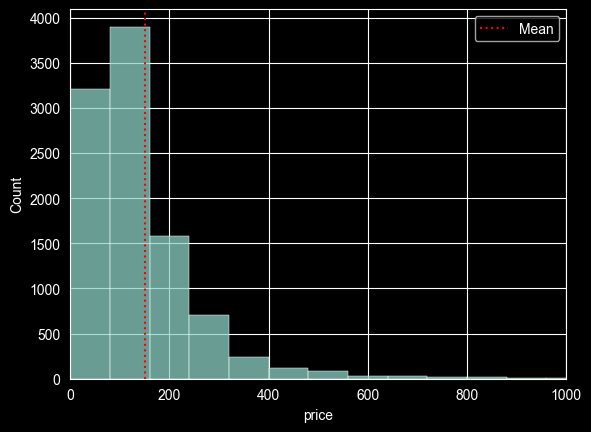

In [63]:
sns.histplot(data=airbnb, x="price", bins=100)
plt.axvline(airbnb['price'].mean(), linestyle="dotted", color="red", label="Mean")
plt.legend()
plt.xlim(0, 1000)
plt.show()

In [64]:
sample_prices = airbnb['price'].head(5).values
avg_price = np.mean(sample_prices)

deviations = sample_prices - avg_price
sum_of_deviations = np.sum(deviations)

print("Sum of all deviations:", round(sum_of_deviations, 15))

Sum of all deviations: -1.4e-14


### **Median**

In [65]:
airbnb['price'].median()
print(airbnb['rating'].median())

4.033448958904051


#### Comparsion of `median` and `average`

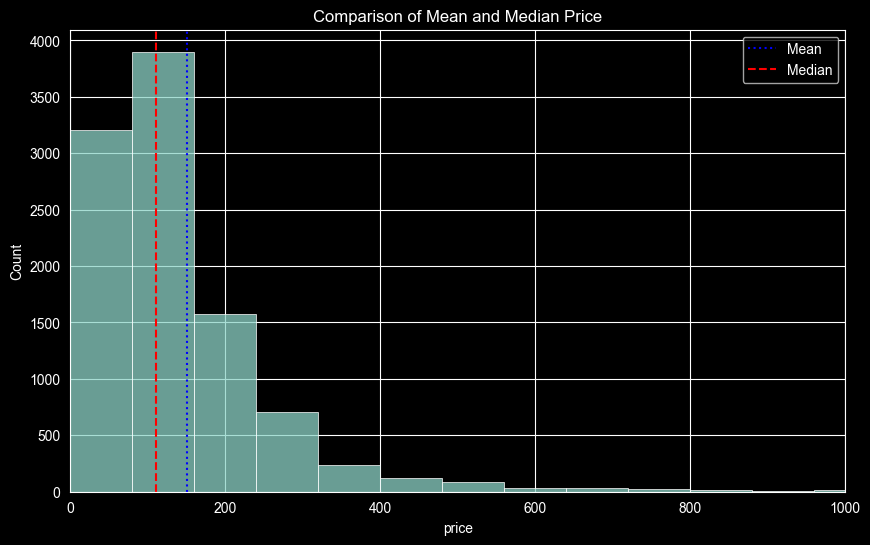

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(data=airbnb, x="price", bins=100)

# Add vertical lines for mean and median
plt.axvline(airbnb['price'].mean(), linestyle="dotted", color="blue", label="Mean")
plt.axvline(airbnb['price'].median(), linestyle="dashed", color="red", label="Median")

plt.legend()
plt.xlim(0, 1000) 
plt.title("Comparison of Mean and Median Price")
plt.show()

#### **Mode**

In [67]:
most_common_room = airbnb['room_type'].mode()[0]
print(f"The most common room type is: '{most_common_room}'")

most_common_neighbourhood = airbnb['neighbourhood_full'].mode()[0]
print(f"The most popular neighbourhood is: '{most_common_neighbourhood}'")

The most common room type is: 'Entire place'
The most popular neighbourhood is: 'Brooklyn, Bedford-Stuyvesant'


In [68]:
print("Categorical Mode (room type):")
print(airbnb['room_type'].mode()[0])

print("\nContinuous Float Mode")
print(airbnb['latitude'].mode().head(5))

Categorical Mode (room type):
Entire place

Continuous Float Mode
0    40.68073
Name: latitude, dtype: float64


#### **Quantiles**


In [69]:
target_quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
calculated_quantiles = airbnb['price'].quantile(target_quantiles)

print("Calculated Price Quantiles summary:")
print(calculated_quantiles)

Calculated Price Quantiles summary:
0.10     50.0
0.25     70.0
0.50    110.0
0.75    175.0
0.90    260.0
0.95    350.0
Name: price, dtype: float64


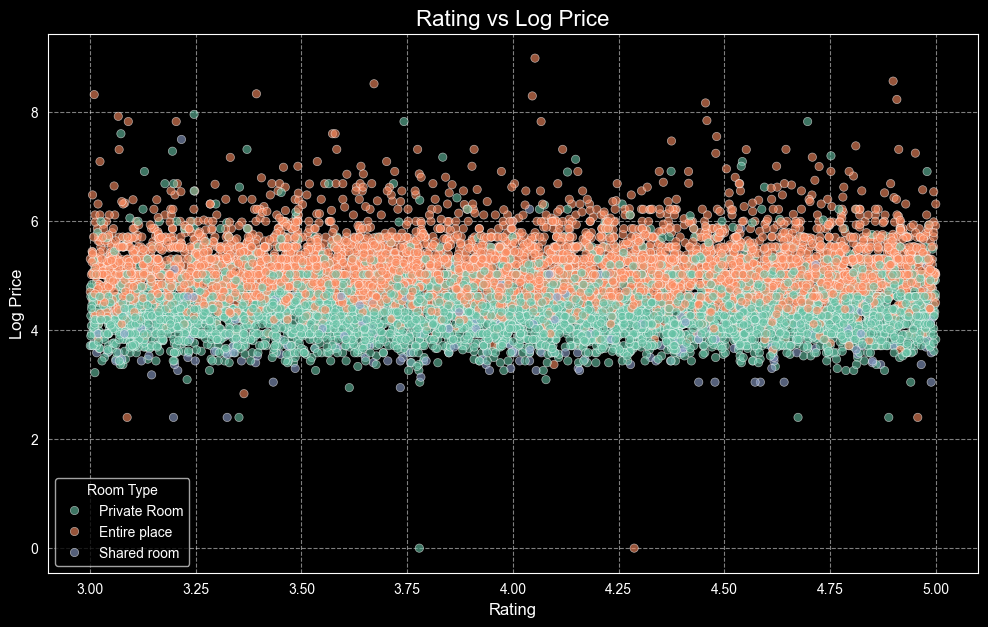

In [70]:

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=airbnb, 
    x='rating', 
    y='logprice', 
    hue='room_type', 
    palette='Set2',
    alpha=0.6
)

plt.title('Rating vs Log Price', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Log Price', fontsize=12)

plt.legend(title='Room Type')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### **Deciles & Percentiles**

In [71]:
decile_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
price_deciles = airbnb['price'].quantile(decile_thresholds)

print("Price Deciles:")
for decile, price in price_deciles.items():
    print(f"D{int(decile*10)} ({decile*100:.0f}th Percentile): ${price:.2f}")

Price Deciles:
D1 (10th Percentile): $50.00
D2 (20th Percentile): $62.00
D3 (30th Percentile): $75.00
D4 (40th Percentile): $92.00
D5 (50th Percentile): $110.00
D6 (60th Percentile): $135.00
D7 (70th Percentile): $150.91
D8 (80th Percentile): $199.00
D9 (90th Percentile): $260.00


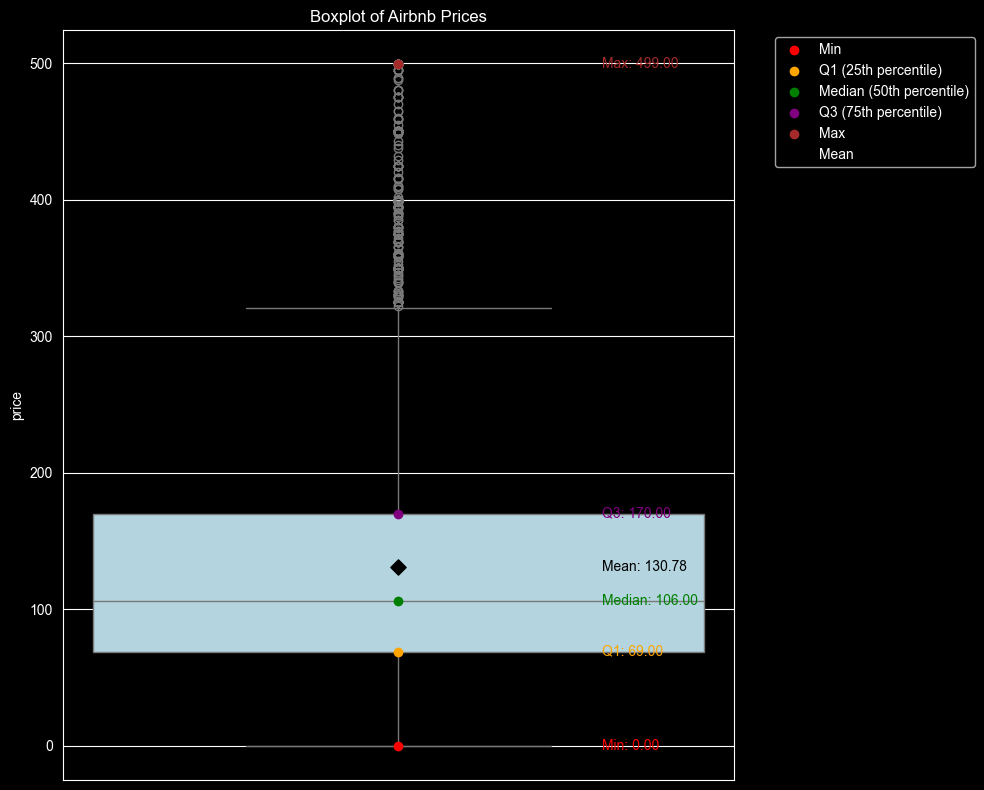

In [72]:
plot_data = airbnb[airbnb['price'] < 500]['price'].dropna() 

fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(y=plot_data, ax=ax, color='lightblue', width=0.3)

minimum = np.min(plot_data)
q1 = np.percentile(plot_data, 25)
median = np.median(plot_data)
q3 = np.percentile(plot_data, 75)
maximum = np.max(plot_data)
mean = np.mean(plot_data)

ax.scatter(0, minimum, color='red', label='Min', zorder=5)
ax.scatter(0, q1, color='orange', label='Q1 (25th percentile)', zorder=5)
ax.scatter(0, median, color='green', label='Median (50th percentile)', zorder=5)
ax.scatter(0, q3, color='purple', label='Q3 (75th percentile)', zorder=5)
ax.scatter(0, maximum, color='brown', label='Max', zorder=5)
ax.scatter(0, mean, color='black', marker='D', s=60, label='Mean', zorder=5)

for value, name, color in zip(
    [minimum, q1, median, mean, q3, maximum],
    ['Min', 'Q1', 'Median', 'Mean', 'Q3', 'Max'],
    ['red', 'orange', 'green', 'black', 'purple', 'brown']
):
    ax.text(0.1, value, f'{name}: {value:.2f}', verticalalignment='center', color=color, fontsize=10)

ax.set_title('Boxplot of Airbnb Prices')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### **Varability**

In [73]:
## range
price_range = airbnb['price'].max() - airbnb['price'].min()

## IQR
Q1 = airbnb['price'].quantile(0.25)
Q3 = airbnb['price'].quantile(0.75)
IQR = Q3 - Q1

## variance
variance = airbnb['price'].var()

## standard deviation
std_dev = airbnb['price'].std()

## coefficient of variation
cv = std_dev / airbnb['price'].mean()

print(f"Range: {price_range}")
print(f"IQR: {IQR}")
print(f"Variance: {variance:.2f}")
print(f"Standard deviation: {std_dev:.2f}")
print(f"Coefficient of variation: {cv:.2f}")

Range: 8000.0
IQR: 105.0
Variance: 41401.21
Standard deviation: 203.47
Coefficient of variation: 1.35


#### **Skewness**

In [74]:
from scipy.stats import skew

price_skewness = skew(airbnb['price'])
print(f"Skewness of Airbnb Prices: {price_skewness:.4f}")



q1_price = airbnb['price'].quantile(0.25)
median_price = airbnb['price'].median()
q3_price = airbnb['price'].quantile(0.75)
iqr_skewness_price = ((q3_price - median_price) - (median_price - q1_price)) / (q3_price - q1_price)
print(f"IQR Skewness: {iqr_skewness_price:.4f}")


Skewness of Airbnb Prices: 14.6092
IQR Skewness: 0.2381


#### **Kurtosis**

In [75]:
from scipy.stats import kurtosis

price_kurtosis = kurtosis(airbnb['price'])
print(f"Kurtosis: {price_kurtosis:.4f}")

Kurtosis: 373.9135


In [76]:
from tabulate import tabulate


def markdown_summary(df, round_decimals=3):
    summary = df.describe()

    summary['Skewness'] = price_skewness
    summary['Kurtosis'] = price_kurtosis

    summary = summary.round(round_decimals)
    return tabulate(summary, headers='keys', tablefmt='github')


print(markdown_summary(airbnb.groupby('room_type')['price']))

| room_type    |   count |    mean |     std |   min |   25% |   50% |   75% |   max |   Skewness |   Kurtosis |
|--------------|---------|---------|---------|-------|-------|-------|-------|-------|------------|------------|
| Entire place |    5184 | 208.598 | 249.002 |     0 |   120 |   160 |   225 |  8000 |     14.609 |    373.913 |
| Private Room |    4603 |  89.802 | 107.973 |     0 |    53 |    70 |    99 |  2850 |     14.609 |    373.913 |
| Shared room  |     226 |  72.904 | 127.992 |    10 |    35 |    50 |    75 |  1800 |     14.609 |    373.913 |


**INTERPRETATION for prices:**

The vast majority of Airbnb listings are densely clustered at the lower end of the pricing scale.

- some of the missing values were imputed with 0 - so hence possible right skewness - for entire place and private room we have min price = 0
- high skewness and kurtosis since we have outliers in our data
- mean is higher than median which confirms the right skewness of our data, which means many smaller priced listings and fewer higher priced listings
- maybe it's due to many outliers/dirty data as min price is 0 or 10 and kurtosis is also very high which means FAT TAILS - so we have a lot of outliers in our data

The high excess kurtosis means that the data has "heavy tails," meaning that while most values are tightly packed together, extreme values are far more distanced than they would be in a standard normal distribution - which could also mean that the highest prices are extremely high, significantly distanced from the mean prices.

There are many offers for entire place (5184) and private rooms (4603), but very few offers for shared rooms (226) - this is a common pattern for airbnb since most people prefer to rent entire places or private rooms rather than shared rooms.

The prices of entire places are higher than private rooms which are higher than shared rooms - this is also a common pattern since entire places are more expensive than private rooms which are more expensive than shared rooms.

There is more variability in the prices of entire places than private rooms and shared rooms as the standard deviation for Entire places (249.00) is drastically higher than for Private Rooms (107.97). This means that while Private rooms stay consistently budget-friendly, Entire places stretch across a huge spectrum—ranging from standard, small apartments to ultra-luxury ones.



In [77]:
print("Median Price by Borough:")
print(airbnb.groupby('borough')['price'].median().sort_values(ascending=False))

print("\nTop 10 Most Expensive Neighbourhoods (Median Price):")
print(airbnb.groupby('neighbourhood')['price'].median().sort_values(ascending=False).head(10))


Median Price by Borough:
borough
Manhattan        150.0
Brooklyn          95.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64

Top 10 Most Expensive Neighbourhoods (Median Price):
neighbourhood
Jamaica Estates      512.5
Unionport            450.0
Flatiron District    275.0
Neponsit             274.0
Kew Gardens Hills    252.0
DUMBO                250.0
Tribeca              250.0
NoHo                 247.5
Vinegar Hill         220.0
Midtown              217.0
Name: price, dtype: float64


# ***BIVARIATE ANALISYS***

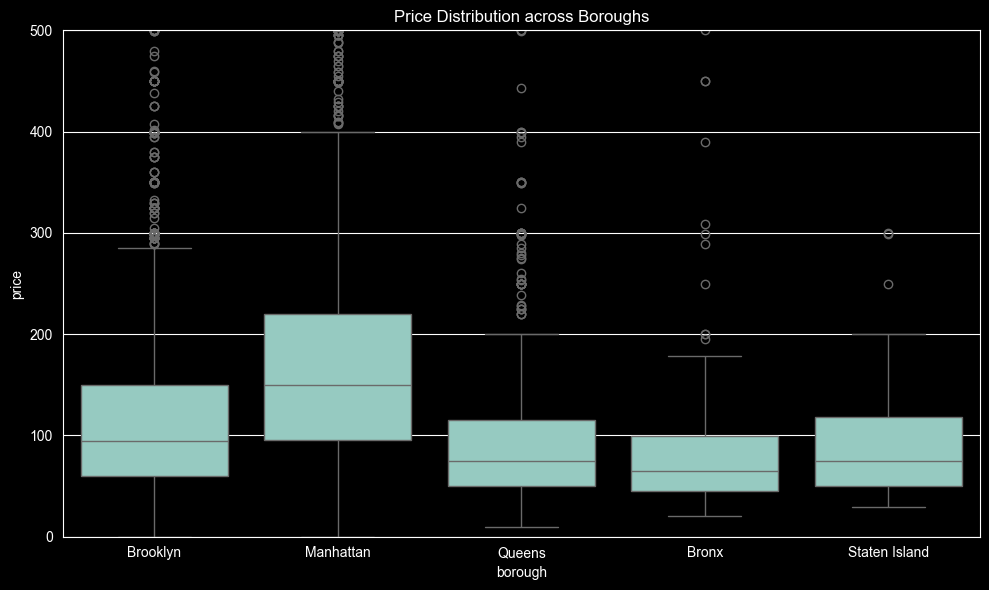

In [78]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=airbnb, x='borough', y='price', ax=ax)
ax.set_ylim(0, 500) # Limiting y-axis to focus on the bulk of data due to high skewness
ax.set_title('Price Distribution across Boroughs')
plt.tight_layout()

**PRICE VS LOCATION**
The most popular location is Bedford-Stuyvesant (in Brooklyn) which is the single most frequent neighborhood in the dataset.

The most expensive borough is Manhattan (median price 150.0), with very wide interquartile range.

Brooklyn is the second most expensive, with more standard range of prices but a lower median than Manhattan.

Queens, the Bronx, and Staten Island have significantly lower median prices and narrower IQRs, showing they are much cheaper options on average.

There are numerous outlier dots stretching upward for almost all boroughs, especially Manhattan and Brooklyn, representing where prices have extreme values, suggesting luxury listings.


### **Calculating Pearson's R** 

PearsonRResult(statistic=np.float64(-0.005322010666937082), pvalue=np.float64(0.5943907029090633))

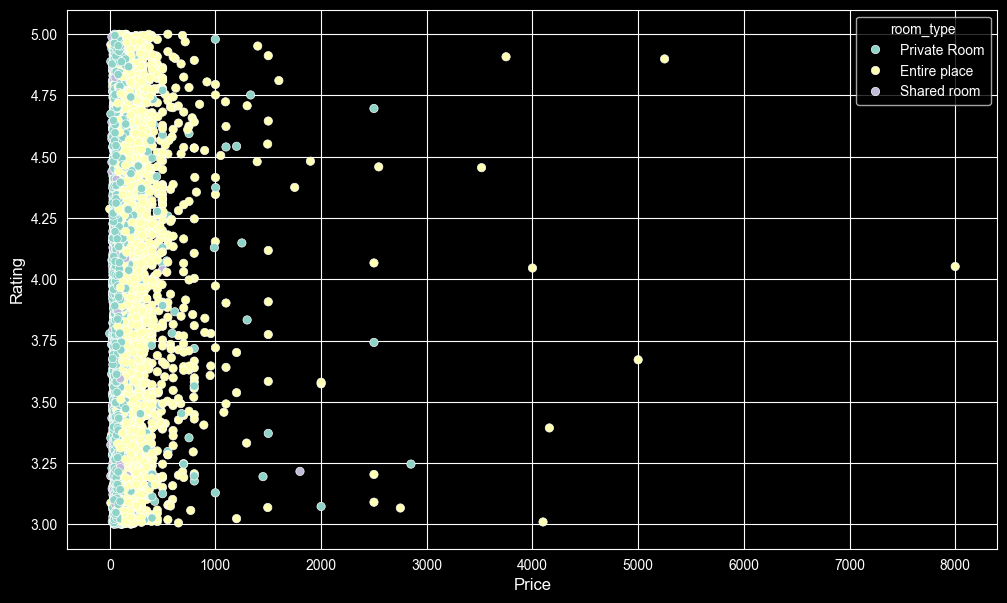

In [79]:
import scipy.stats as ss

plt.figure(figsize=(12,7))

sns.scatterplot(data=airbnb, x='price', y='rating', hue='room_type')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Rating', fontsize=12)

ss.pearsonr(airbnb['price'], airbnb['rating'])

The calculated Pearson's $r$ between  price and customer ratings is extremely close to 0. This indicates that there is no linear relationship between how much a listing costs and the score it receives from guests.

### **Kendall's**

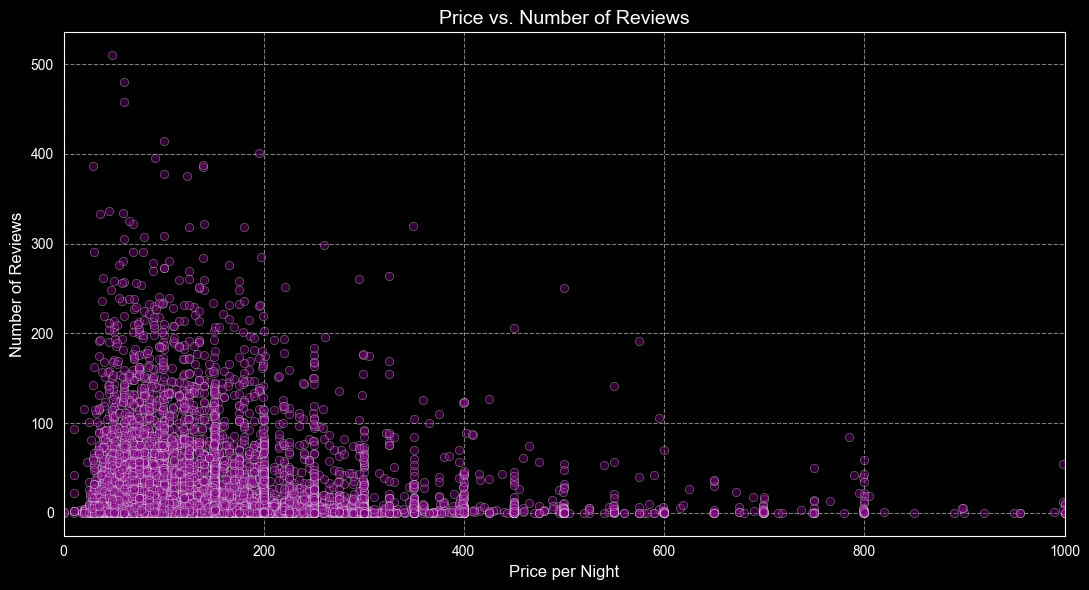

Kendall's rank correlation coefficient: -0.0321
P-value: 3.4624341528456484e-06


In [80]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=airbnb, x='price', y='number_of_reviews', color='purple', alpha=0.4)
plt.title('Price vs. Number of Reviews', fontsize=14)
plt.xlabel('Price per Night', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xlim(0, 1000) # focusing on the bulk of data due to high price outliers
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Kendall's Tau Rank Correlation
kendall_tau, kendall_p = ss.kendalltau(airbnb['price'], airbnb['number_of_reviews'])
print(f"Kendall's rank correlation coefficient: {kendall_tau:.4f}")
print(f"P-value: {kendall_p}")

Kendall's rank correlation coefficient is extremely close to 0. This indicates that there is no linear nor non-linear relationship between how much a listing costs and the number of reviews it receives from guests.

### **Heatmap**

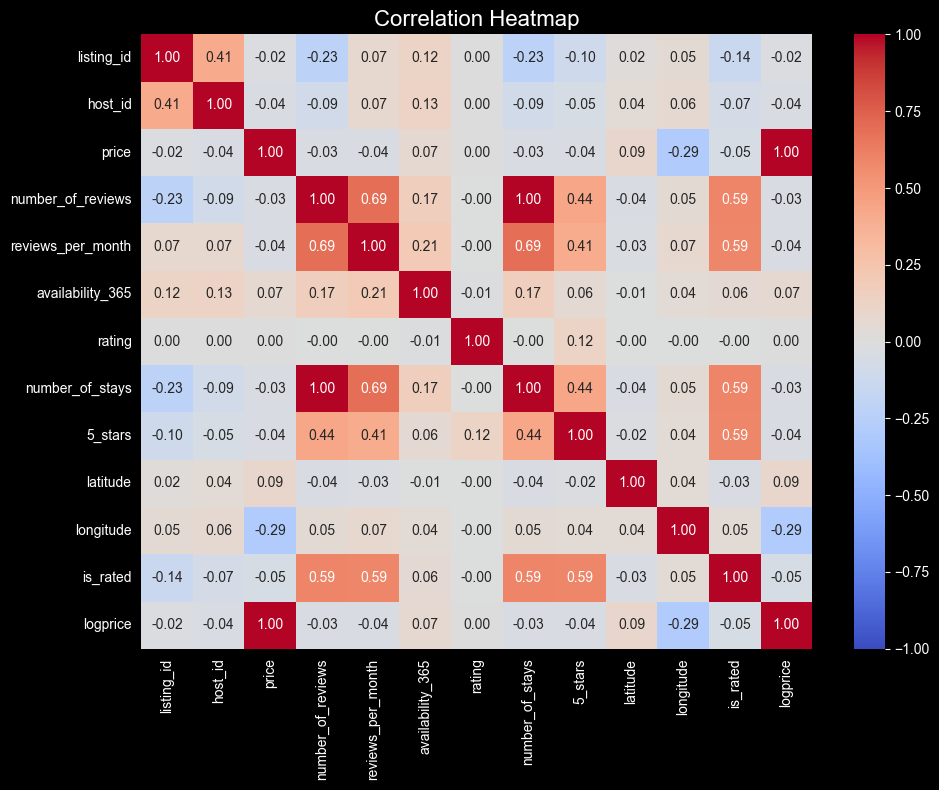

In [81]:
# Compute correlation matrix
corr = airbnb.corr(numeric_only=True, method="kendall") #kendall -> not just linear corellations

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(corr,
            annot=True,         # Show correlation coefficients
            fmt=".2f",          # Format for coefficients
            cmap="coolwarm",    # Color palette
            vmin=-1, vmax=1)    # Fixed scale

# Title and layout
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()

# Show plot
plt.show()

**REVIEWS**
There is a strong positive correlation between reviews_per_month and number_of_stays. Listings that have more guests naturally get more reviews every month. It also shows that our data cleaning and missing value fixes worked correctly. Simillarly with correlation between reviews_per_month and availability_365 - naturally meaning that more available places are rated more often.

There is a weak to moderate correlation between 5 stars reviews and place being rated (0.59), also between 5 stars reviews and reviews_per_month (0.41), suggesting that when guest are happy with the stay, they're more likely to rate it with 5 stars and people less happy with they stay a little less likely to leave it a review. This also can suggest that places rated often, receive more positive (5 stars) reviews which also contributes to their overall popularity and hence likelihood of getting more reviews.

**PRICE VS COORDINATES**
There is a weak negative correlation (-0.29) between longitude coordinate of the place and price, but almost no correlation between latitude and price (0.09). This means that as longitude value gets bigger (in this dataset meaning we go in the direction of East in the New York), the prices get a little bit lower. Prices depend on specific popular neighborhoods, not just simple map lines, as discussed earlier in the PRICE VS LOCATION section.


**PRICE VS RATING**
The Kendall's Tau correlation coefficient between price and rating is approximately 0.01, this means that there is no correlation between rating and prices. A higher price does not guarantee a higher rating, and a low price does not mean a low rating. More expensive listings are just as likely to have low ratings as cheap listings. It can suggest that customer satisfaction is not related to the price/luxury of the place but maybe to the price to quality ratio or just meeting the expectations.

### **Correlation of Qualitative Variables**

### **PRICE CATEGORY VS ROOM TYPE**

In [82]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

observed_table = pd.crosstab(index=airbnb['price_cat'], columns=airbnb['room_type'])
print("Observed Contingency Table:")
print(observed_table)
print("-" * 50)

chi2, p, dof, expected = chi2_contingency(observed_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")


cramers_v = association(observed_table, method="cramer")
print(f"Cramér's V: {cramers_v:.4f}")

Observed Contingency Table:
room_type     Entire place  Private Room  Shared room
price_cat                                            
(0, 100]               892          3678          199
(100, 200]            2739           789           23
(200, 300]             976            64            0
(300, 400]             288            29            2
(400, 500]             112            14            1
(500, 600]              53             4            0
(600, 1000]             83            12            0
(1000, 2000]            27             9            1
(2000, 5000]            11             3            0
(5000, 8000]             2             0            0
--------------------------------------------------
Chi-Square Statistic: 4104.1187
p-value: 0.0000
Degrees of Freedom: 18
Cramér's V: 0.4527


- Private Rooms dominate the budget segment (0–100 USD): 3,678 listings vs 892 Entire places.
  This presents renting a spare room as the most common option withid the cheapest ones.

- Entire places take over in the mid-to-high range (100–300 USD): guests paying more
  expect full privacy and space, which only entire apartments provide.

- Shared rooms are almost absent above 200 USD (only 2 listings in 200–300 range),
  confirming they serve purely as a budget alternative.

- The Cramér's V coefficient (0.45) indicates a moderate-to-strong practical
  association — room type is one of the strongest predictors of price tier.

### **BOROUGH VS ROOM TYPE**

In [84]:
observed_table = pd.crosstab(
    index=airbnb['borough'],
    columns=airbnb['room_type'],
    margins=True,
    margins_name='Total'
)
print("Observed Contingency Table:")
print(observed_table)
print("-" * 60)

pct_table = pd.crosstab(
    index=airbnb['borough'],
    columns=airbnb['room_type'],
    normalize='index'
).round(3) * 100
print("\nRow-percentage Table (%):")
print(pct_table)
print("-" * 60)

Observed Contingency Table:
room_type      Entire place  Private Room  Shared room  Total
borough                                                      
Bronx                    75           138           16    229
Brooklyn               1907          2102           75   4084
Manhattan              2748          1597          101   4446
Queens                  421           727           33   1181
Staten Island            33            39            1     73
Total                  5184          4603          226  10013
------------------------------------------------------------

Row-percentage Table (%):
room_type      Entire place  Private Room  Shared room
borough                                               
Bronx                  32.8          60.3          7.0
Brooklyn               46.7          51.5          1.8
Manhattan              61.8          35.9          2.3
Queens                 35.6          61.6          2.8
Staten Island          45.2          53.4          1.4
---

In [85]:
observed_no_margins = pd.crosstab(
    index=airbnb['borough'],
    columns=airbnb['room_type']
)
chi2, p, dof, expected = chi2_contingency(observed_no_margins)
cramers_v = association(observed_no_margins, method="cramer")

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"p-value              : {p:.6f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramér's V           : {cramers_v:.4f}")


Chi-Square Statistic : 408.4582
p-value              : 0.000000
Degrees of Freedom   : 8
Cramér's V           : 0.1428


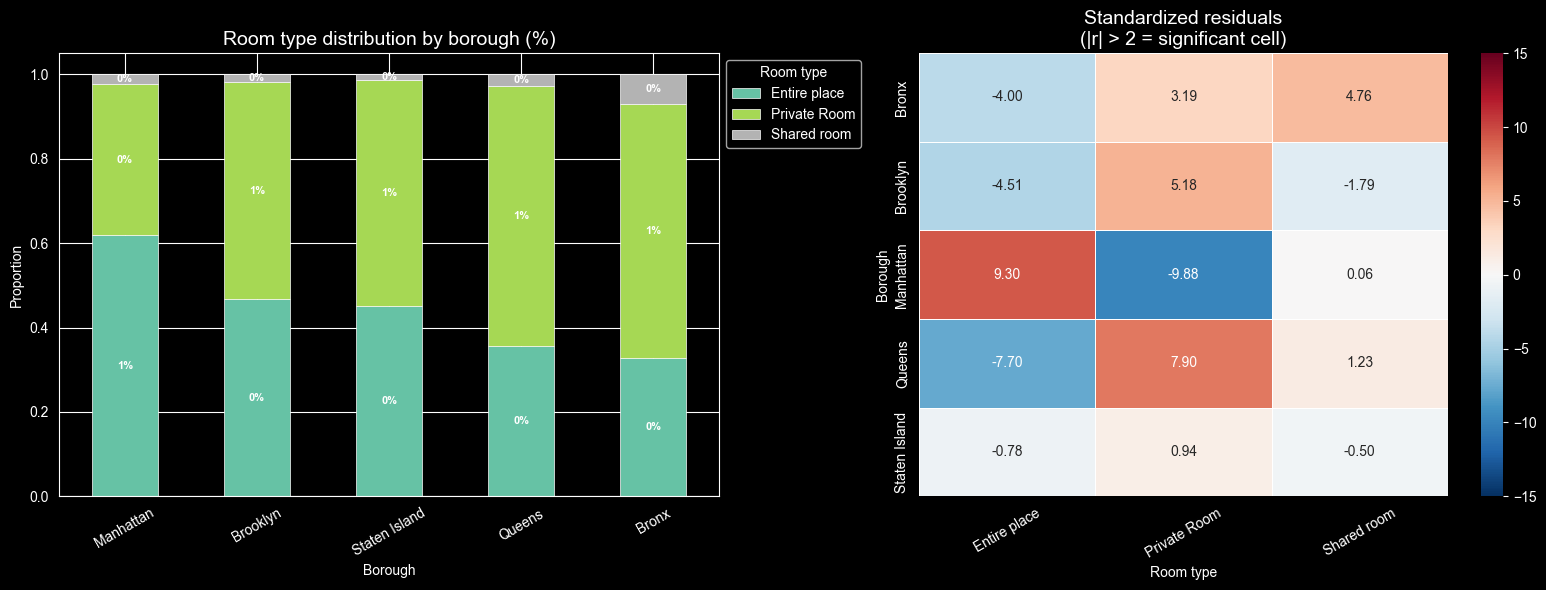

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pct_plot = pd.crosstab(
    index=airbnb['borough'],
    columns=airbnb['room_type'],
    normalize='index'
).sort_values('Entire place', ascending=False)

pct_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='Set2',
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_title('Room type distribution by borough (%)', fontsize=14)
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Room type', bbox_to_anchor=(1.0, 1), loc='upper left')

for bar_group in axes[0].containers:
    axes[0].bar_label(bar_group, fmt='%.0f%%',
                      label_type='center', fontsize=8,
                      color='white', fontweight='bold')


observed_vals = observed_no_margins.values
expected_vals = expected

std_residuals = (observed_vals - expected_vals) / np.sqrt(expected_vals)
std_resid_df = pd.DataFrame(
    std_residuals,
    index=observed_no_margins.index,
    columns=observed_no_margins.columns
)

sns.heatmap(
    std_resid_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-15, vmax=15,
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Standardized residuals\n(|r| > 2 = significant cell)', fontsize=14)
axes[1].set_xlabel('Room type')
axes[1].set_ylabel('Borough')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**borough VS room_type**

Chi-Square = 408.46, p ≈ 0.000000
The relationship is statistically significant, meaning that the probability that such a distribution arose by chance is practically zero. With 5 boroughs × 3 room types = 8 degrees of freedom, the value of 408 is very high.
Cramér's V = 0.1428 means that we have a weak practical relationship, despite a very strong statistical one. This Cramer's V value means that knowledge of the borough explains almost none of the variance in room type. Borough has an impact on room_type, but it is a weak impact - other factors (e.g. price, host) are more important.

Although Cramér's V = 0.14 indicates a weak overall association, the standardized residuals reveal that the signal is highly concentrated in two boroughs: Manhattan and Queens.

Manhattan (+9.30 Entire place / −9.88 Private Room) is a structural outlier — it has far more full-apartment rentals than any other borough. This reflects its premium tourism market: guests visiting Manhattan expect and can afford full privacy, and hosts respond by listing entire apartments rather than rooms.

Queens (−7.70 / +7.90) and Brooklyn (−4.51 / +5.18) show the opposite - Private Rooms dominate over Entire place. These are residential boroughs where hosts rent out spare rooms, not entire units.

The Bronx stands out for Shared room over-representation (+4.76) — the only borough where this budget option appears above chance levels, suggesting the most of the low-budget guests decide to stay there.

Staten Island shows no significant deviation in any cell (all residuals < 1), meaning its room type mix perfectly mirrors the citywide average. It is the most "typical" borough in terms of listing structure.


**Conclusion** can be that the weak Cramér's V masks a polarized market. Manhattan is significantly different from outer boroughs — not just in price, but in the type of hosting model.
The NYC Airbnb market could be divided into two distinct segments: Manhattan (entire-apartment, high-end) vs.
outer boroughs (room-sharing, budget-oriented).